# 🧠 Alzheimer's Cognitive Progression Prediction Model

This notebook simulates a **20-question weekly quiz** administered to Alzheimer's patients  
(3–4 sessions per week), models their cognitive decline over 52 weeks, and **predicts**  
when each patient will transition to the next disease stage.

---

### Quiz Structure (Max 20 points)
| Domain | Questions | Max Score |
|---|---|---|
| Orientation | Date, day, month, year, season, city, state, floor | 8 |
| Memory | Recall 3 words + public figure | 4 |
| Attention | Serial 7s, WORLD backwards, count by 2s | 4 |
| Language | Name object, repeat phrase | 2 |
| Visuospatial | Copy pentagons, draw clock | 2 |

### Stage Classification
| Stage | Score Range | Interpretation |
|---|---|---|
| Normal | 18–20 | No impairment |
| MCI | 15–17 | Mild Cognitive Impairment |
| Mild | 11–14 | Mild Alzheimer's |
| Moderate | 6–10 | Moderate Alzheimer's |
| Severe | 0–5 | Severe Alzheimer's |


In [1]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

np.random.seed(99)
print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Configuration — Stages, Questions, Patient Profiles

In [2]:
# ── STAGE DEFINITIONS ────────────────────────────────────────────────────────
STAGES = [
    {"name": "Normal",   "min": 18, "max": 20, "color": "#2ecc71"},
    {"name": "MCI",      "min": 15, "max": 17, "color": "#f1c40f"},
    {"name": "Mild",     "min": 11, "max": 14, "color": "#e67e22"},
    {"name": "Moderate", "min": 6,  "max": 10, "color": "#e74c3c"},
    {"name": "Severe",   "min": 0,  "max": 5,  "color": "#8e1a0e"},
]
STAGE_COLORS = {s["name"]: s["color"] for s in STAGES}

def get_stage(score):
    for s in STAGES:
        if s["min"] <= score <= s["max"]:
            return s
    return STAGES[-1]

# ── 20 QUESTIONS ──────────────────────────────────────────────────────────────
QUESTIONS = [
    # Orientation (8 pts)
    {"id":1, "cat":"Orientation",  "q":"What is today's date?"},
    {"id":2, "cat":"Orientation",  "q":"What day of the week is it?"},
    {"id":3, "cat":"Orientation",  "q":"What month is it?"},
    {"id":4, "cat":"Orientation",  "q":"What year is it?"},
    {"id":5, "cat":"Orientation",  "q":"What season are we in?"},
    {"id":6, "cat":"Orientation",  "q":"What city are you in?"},
    {"id":7, "cat":"Orientation",  "q":"What state/country are you in?"},
    {"id":8, "cat":"Orientation",  "q":"What floor of the building are you on?"},
    # Memory (4 pts)
    {"id":9,  "cat":"Memory",      "q":"Recall word 1 (shown 5 min ago)"},
    {"id":10, "cat":"Memory",      "q":"Recall word 2 (shown 5 min ago)"},
    {"id":11, "cat":"Memory",      "q":"Recall word 3 (shown 5 min ago)"},
    {"id":12, "cat":"Memory",      "q":"Name the current Prime Minister/President"},
    # Attention (4 pts)
    {"id":13, "cat":"Attention",   "q":"Subtract 7 from 100 (answer 93?)"},
    {"id":14, "cat":"Attention",   "q":"Subtract 7 again (answer 86?)"},
    {"id":15, "cat":"Attention",   "q":"Spell WORLD backwards"},
    {"id":16, "cat":"Attention",   "q":"Count backward from 20 by 2s"},
    # Language (2 pts)
    {"id":17, "cat":"Language",    "q":"Name this object (shown: pencil)"},
    {"id":18, "cat":"Language",    "q":"Repeat: 'No ifs, ands, or buts'"},
    # Visuospatial (2 pts)
    {"id":19, "cat":"Visuospatial","q":"Copy the intersecting pentagons"},
    {"id":20, "cat":"Visuospatial","q":"Draw a clock showing 10 past 11"},
]

CATEGORIES = ["Orientation", "Memory", "Attention", "Language", "Visuospatial"]
CAT_MAX    = {"Orientation": 8, "Memory": 4, "Attention": 4, "Language": 2, "Visuospatial": 2}

# ── PATIENT PROFILES ──────────────────────────────────────────────────────────
PATIENT_PROFILES = {
    "P001": {"name": "Arjun S.",  "start_score": 19.8, "decline_rate": 0.0028, "noise": 0.10, "color": "#4a9eff"},
    "P002": {"name": "Meena R.",  "start_score": 16.5, "decline_rate": 0.0045, "noise": 0.14, "color": "#b06dff"},
    "P003": {"name": "Ravi K.",   "start_score": 13.5, "decline_rate": 0.0060, "noise": 0.12, "color": "#ff8c42"},
}

print(f"Configured {len(QUESTIONS)} questions across {len(CATEGORIES)} domains")
print(f"Patients: {[p['name'] for p in PATIENT_PROFILES.values()]}")


Configured 20 questions across 5 domains
Patients: ['Arjun S.', 'Meena R.', 'Ravi K.']


## 2. Data Generation — 3–4 Sessions per Week, 52 Weeks

In [3]:
def generate_sessions(profile_id, num_weeks=52):
    """
    Simulate quiz sessions for one patient.
    - 3 or 4 sessions per week (randomly chosen)
    - Quadratic decline: slow at first, accelerates over time
    - Memory domain declines fastest; Language most preserved
    """
    p     = PATIENT_PROFILES[profile_id]
    s0    = p["start_score"]
    dr    = p["decline_rate"]
    noise = p["noise"]

    # Per-domain decline rates (Memory fastest, Language slowest)
    cat_dr = {
        "Orientation":  dr * np.random.uniform(0.8, 1.0),
        "Memory":       dr * np.random.uniform(1.2, 1.5),
        "Attention":    dr * np.random.uniform(0.9, 1.2),
        "Language":     dr * np.random.uniform(0.5, 0.8),
        "Visuospatial": dr * np.random.uniform(0.7, 1.1),
    }

    records = []
    session_num  = 0
    current_date = datetime(2024, 1, 1)

    for week in range(num_weeks):
        n_sessions = np.random.choice([3, 4], p=[0.4, 0.6])
        session_days = sorted(np.random.choice(range(7), n_sessions, replace=False))

        for d in session_days:
            t = session_num
            cat_scores = {}
            for cat in CATEGORIES:
                max_pt = CAT_MAX[cat]
                cat_s0 = s0 * (max_pt / 20)
                decay  = cat_dr[cat] * t + 0.00002 * t**2   # quadratic
                raw    = cat_s0 * (1 - decay) + np.random.normal(0, noise * max_pt)
                cat_scores[cat] = int(np.clip(round(raw), 0, max_pt))

            total = int(np.clip(sum(cat_scores.values()), 0, 20))
            stage = get_stage(total)

            records.append({
                "patient_id":       profile_id,
                "patient_name":     p["name"],
                "session_num":      session_num + 1,
                "date":             (current_date + timedelta(days=int(d))).strftime("%Y-%m-%d"),
                "week":             week + 1,
                "total_score":      total,
                "max_score":        20,
                "percentage":       round(total / 20 * 100, 1),
                "stage":            stage["name"],
                "score_orientation":cat_scores["Orientation"],
                "score_memory":     cat_scores["Memory"],
                "score_attention":  cat_scores["Attention"],
                "score_language":   cat_scores["Language"],
                "score_visuospatial":cat_scores["Visuospatial"],
            })
            session_num += 1

        current_date += timedelta(days=7)

    return pd.DataFrame(records)

# Generate all patients
patients = {pid: generate_sessions(pid) for pid in PATIENT_PROFILES}
all_data = pd.concat(patients.values(), ignore_index=True)

print(f"Total sessions generated : {len(all_data)}")
print(f"Date range               : {all_data.date.min()} → {all_data.date.max()}")
print(f"\nSessions per patient:")
print(all_data.groupby(["patient_id","patient_name"])["session_num"].count().to_string())


Total sessions generated : 561
Date range               : 2024-01-01 → 2024-12-29

Sessions per patient:
patient_id  patient_name
P001        Arjun S.        189
P002        Meena R.        190
P003        Ravi K.         182


### Preview the Grade History

In [4]:
# Show first 10 sessions for Patient P001
sample = all_data[all_data.patient_id == "P001"].head(10)
sample.style.background_gradient(subset=["total_score","percentage"], cmap="RdYlGn") \
      .format({"percentage": "{:.1f}%"})


,patient_id,patient_name,session_num,date,week,total_score,max_score,percentage,stage,score_orientation,score_memory,score_attention,score_language,score_visuospatial
0,P001,Arjun S.,1,2024-01-01,1,19,20,95.0%,Normal,7,4,4,2,2
1,P001,Arjun S.,2,2024-01-03,1,17,20,85.0%,MCI,7,3,3,2,2
2,P001,Arjun S.,3,2024-01-05,1,18,20,90.0%,Normal,7,3,4,2,2
3,P001,Arjun S.,4,2024-01-06,1,19,20,95.0%,Normal,8,4,3,2,2
4,P001,Arjun S.,5,2024-01-08,2,19,20,95.0%,Normal,7,4,4,2,2
5,P001,Arjun S.,6,2024-01-10,2,18,20,90.0%,Normal,7,4,3,2,2
6,P001,Arjun S.,7,2024-01-13,2,20,20,100.0%,Normal,8,4,4,2,2
7,P001,Arjun S.,8,2024-01-15,3,18,20,90.0%,Normal,7,4,3,2,2
8,P001,Arjun S.,9,2024-01-17,3,20,20,100.0%,Normal,8,4,4,2,2
9,P001,Arjun S.,10,2024-01-20,3,20,20,100.0%,Normal,8,4,4,2,2


In [5]:
# Save full grade history to CSV
csv_path = "alzheimers_grade_history.csv"
all_data.to_csv(csv_path, index=False)
print(f"Saved {len(all_data)} rows to {csv_path}")
print(f"Columns: {list(all_data.columns)}")


Saved 561 rows to alzheimers_grade_history.csv
Columns: ['patient_id', 'patient_name', 'session_num', 'date', 'week', 'total_score', 'max_score', 'percentage', 'stage', 'score_orientation', 'score_memory', 'score_attention', 'score_language', 'score_visuospatial']


## 3. Prediction Engine — Linear Regression on Score Trajectory

In [6]:
def predict_progression(df, use_weeks=26):
    """
    Fit linear regression on first `use_weeks` of data.
    Project forward to estimate when each stage transition occurs.
    
    Returns dict with slope, R², current stage, and predictions list.
    """
    sub = df[df["week"] <= use_weeks].copy()
    if len(sub) < 15:
        return None

    X = sub["session_num"].values.reshape(-1, 1)
    y = sub["total_score"].values

    model = LinearRegression().fit(X, y)
    slope     = model.coef_[0]
    intercept = model.intercept_
    r2        = r2_score(y, model.predict(X))

    last_session  = sub["session_num"].max()
    last_date     = pd.to_datetime(sub["date"].max())
    last_score    = int(np.clip(round(intercept + slope * last_session), 0, 20))
    current_stage = get_stage(last_score)
    avg_per_week  = 3.5  # average sessions per week

    predictions = []
    for stage in STAGES:
        if stage["min"] >= current_stage["min"] or slope >= 0:
            continue
        target = stage["max"]
        sessions_from_now = ((target - intercept) / slope) - last_session
        if sessions_from_now <= 0:
            continue
        weeks_from_now = sessions_from_now / avg_per_week
        predictions.append({
            "next_stage":      stage["name"],
            "sessions_needed": int(round(sessions_from_now)),
            "weeks_from_now":  round(weeks_from_now, 1),
            "months_from_now": round(weeks_from_now / 4.33, 1),
            "est_date":        (last_date + timedelta(weeks=weeks_from_now)).strftime("%b %Y"),
            "confidence_pct":  min(97, int(r2 * 100)),
        })

    return {
        "slope":            slope,
        "intercept":        intercept,
        "r2":               r2,
        "current_stage":    current_stage,
        "last_score":       last_score,
        "predictions":      predictions,
        "decline_per_week": abs(slope) * avg_per_week,
        "sub":              sub,
    }

# Run predictions for all patients (fit on first 26 weeks)
results = {pid: predict_progression(df, use_weeks=26) for pid, df in patients.items()}
print("Predictions computed ✓")


Predictions computed ✓


### Prediction Report

In [7]:
print("=" * 65)
print("  ALZHEIMER'S STAGE TRANSITION PREDICTION REPORT")
print("  Model fit on first 26 weeks of sessions")
print("=" * 65)

for pid, res in results.items():
    p = PATIENT_PROFILES[pid]
    print(f"\n  {p['name']} ({pid})")
    print(f"  Sessions in fit      : {len(res['sub'])}")
    print(f"  Score @ week 26      : {res['last_score']}/20  [{res['current_stage']['name']}]")
    print(f"  Decline rate         : {res['decline_per_week']:.3f} pts / week")
    print(f"  Model R²             : {res['r2']:.3f}")
    if res["predictions"]:
        for pr in res["predictions"][:3]:
            print(f"  → {pr['next_stage']:10s} : ~{pr['weeks_from_now']} weeks "
                  f"({pr['months_from_now']} mo) by {pr['est_date']}  "
                  f"[confidence: {pr['confidence_pct']}%]")
    else:
        print("  → Already at final stage or no projection possible")


  ALZHEIMER'S STAGE TRANSITION PREDICTION REPORT
  Model fit on first 26 weeks of sessions

  Arjun S. (P001)
  Sessions in fit      : 95
  Score @ week 26      : 11/20  [Mild]
  Decline rate         : 0.334 pts / week
  Model R²             : 0.807
  → Moderate   : ~4.2 weeks (1.0 mo) by Jul 2024  [confidence: 80%]
  → Severe     : ~19.2 weeks (4.4 mo) by Nov 2024  [confidence: 80%]

  Meena R. (P002)
  Sessions in fit      : 95
  Score @ week 26      : 7/20  [Moderate]
  Decline rate         : 0.373 pts / week
  Model R²             : 0.744
  → Severe     : ~5.1 weeks (1.2 mo) by Aug 2024  [confidence: 74%]

  Ravi K. (P003)
  Sessions in fit      : 89
  Score @ week 26      : 5/20  [Severe]
  Decline rate         : 0.326 pts / week
  Model R²             : 0.737
  → Already at final stage or no projection possible


In [8]:
# Build a clean forecast summary table
rows = []
for pid, res in results.items():
    p = PATIENT_PROFILES[pid]
    if res["predictions"]:
        for pr in res["predictions"][:3]:
            rows.append({
                "Patient":          p["name"],
                "Patient ID":       pid,
                "Score @ cutoff":   f"{res['last_score']}/20",
                "Current Stage":    res["current_stage"]["name"],
                "Decline (pts/wk)": round(res["decline_per_week"], 3),
                "R²":               round(res["r2"], 3),
                "Next Stage":       pr["next_stage"],
                "Est. Weeks":       pr["weeks_from_now"],
                "Est. Months":      pr["months_from_now"],
                "Est. Date":        pr["est_date"],
                "Confidence":       f"{pr['confidence_pct']}%",
            })

forecast_df = pd.DataFrame(rows)
forecast_df.style.map(
    lambda v: f"color: {STAGE_COLORS.get(v, 'black')}; font-weight: bold",
    subset=["Current Stage", "Next Stage"]
)


,Patient,Patient ID,Score @ cutoff,Current Stage,Decline (pts/wk),R²,Next Stage,Est. Weeks,Est. Months,Est. Date,Confidence
0,Arjun S.,P001,11/20,Mild,0.334000,0.807000,Moderate,4.200000,1.000000,Jul 2024,80%
1,Arjun S.,P001,11/20,Mild,0.334000,0.807000,Severe,19.200000,4.400000,Nov 2024,80%
2,Meena R.,P002,7/20,Moderate,0.373000,0.744000,Severe,5.100000,1.200000,Aug 2024,74%


## 4. Visualisations

### 4.1 — Score Trajectories (Full 52 Weeks)

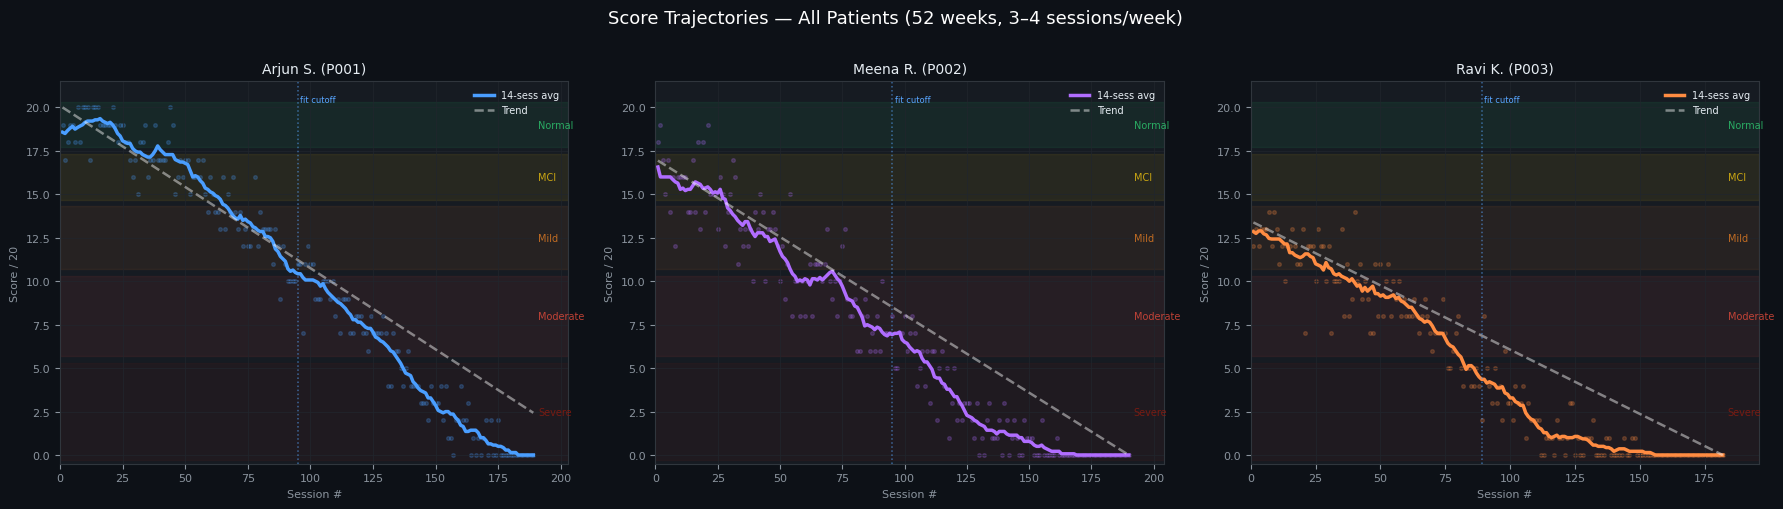

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0d1117")
fig.suptitle("Score Trajectories — All Patients (52 weeks, 3–4 sessions/week)",
             fontsize=13, color="white", y=1.01)

BG = "#161b22"; GRID = "#21262d"; MUTED = "#8b949e"; TEXT = "#e6edf3"; BORDER = "#30363d"

for ax, (pid, df) in zip(axes, patients.items()):
    ax.set_facecolor(BG)
    p   = PATIENT_PROFILES[pid]
    res = results[pid]

    # Stage bands
    for s in STAGES:
        ax.axhspan(s["min"]-0.3, s["max"]+0.3, alpha=0.08, color=s["color"])
        ax.text(df.session_num.max()*1.01, (s["min"]+s["max"])/2,
                s["name"], fontsize=7, color=s["color"], va="center", alpha=0.8)

    ax.scatter(df.session_num, df.total_score, s=7, alpha=0.22, color=p["color"])
    roll = df.total_score.rolling(14, center=True, min_periods=4).mean()
    ax.plot(df.session_num, roll, lw=2.5, color=p["color"], label="14-sess avg")

    m, b = res["slope"], res["intercept"]
    xr = np.array([1, df.session_num.max()])
    ax.plot(xr, np.clip(b + m * xr, 0, 20), "--", lw=1.8, color="white", alpha=0.45, label="Trend")
    cutoff = res["sub"].session_num.max()
    ax.axvline(cutoff, color="#58a6ff", lw=1.1, alpha=0.55, linestyle=":")
    ax.text(cutoff+1, 20.3, "fit cutoff", fontsize=6, color="#58a6ff")

    ax.set_title(f"{p['name']} ({pid})", fontsize=10, color=TEXT, pad=6)
    ax.set_xlabel("Session #", fontsize=8, color=MUTED)
    ax.set_ylabel("Score / 20", fontsize=8, color=MUTED)
    ax.set_xlim(0, df.session_num.max() + 14)
    ax.set_ylim(-0.5, 21.5)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.grid(True, color=GRID, linewidth=0.5)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.legend(fontsize=7, framealpha=0, labelcolor=TEXT)

plt.tight_layout()
plt.show()


### 4.2 — Stage Transition Forecast (26-week fit + projection)

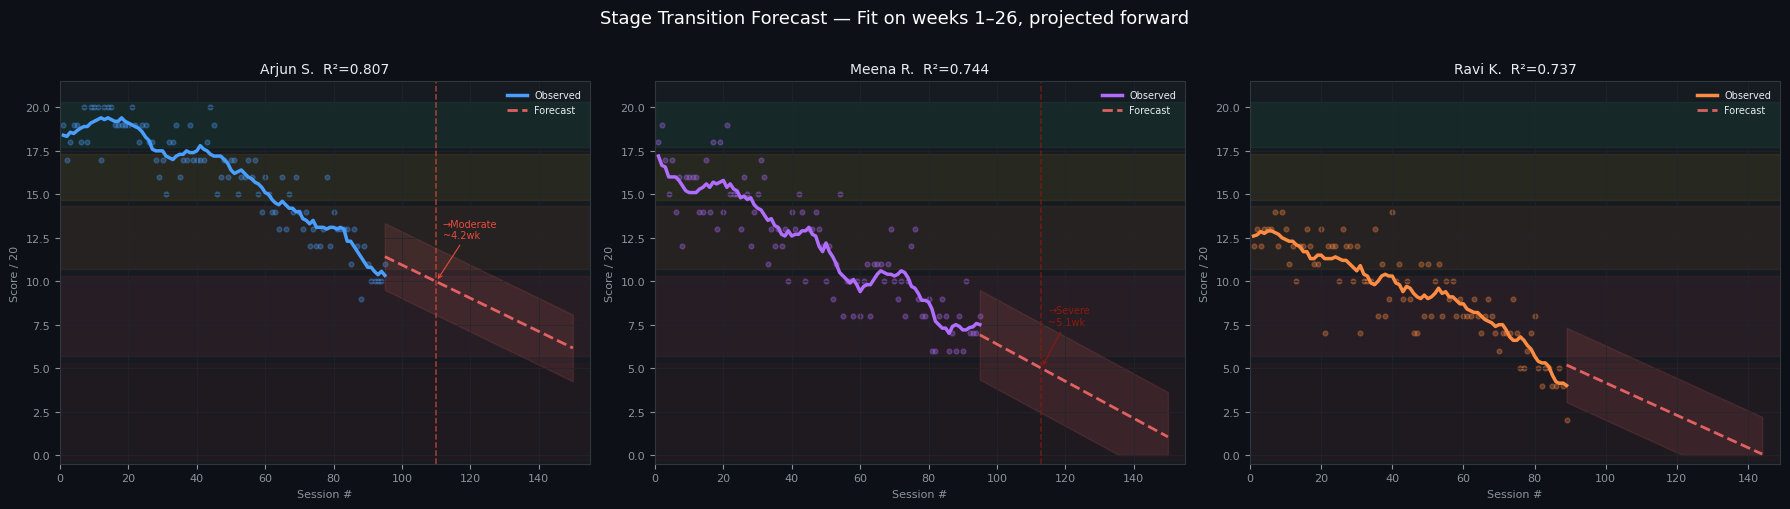

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0d1117")
fig.suptitle("Stage Transition Forecast — Fit on weeks 1–26, projected forward",
             fontsize=13, color="white", y=1.01)

for ax, (pid, df) in zip(axes, patients.items()):
    ax.set_facecolor(BG)
    p   = PATIENT_PROFILES[pid]
    res = results[pid]
    sub = res["sub"]
    m, b = res["slope"], res["intercept"]

    for s in STAGES:
        ax.axhspan(s["min"]-0.3, s["max"]+0.3, alpha=0.08, color=s["color"])

    ax.scatter(sub.session_num, sub.total_score, s=12, alpha=0.30, color=p["color"])
    roll = sub.total_score.rolling(10, center=True, min_periods=3).mean()
    ax.plot(sub.session_num, roll, lw=2.5, color=p["color"], label="Observed")

    last_s = sub.session_num.max()
    fx = np.linspace(last_s, last_s + 55, 100)
    fy = np.clip(b + m * fx, 0, 20)
    ax.plot(fx, fy, "--", lw=2, color="#ff6b6b", alpha=0.85, label="Forecast")

    resid_std = np.std(sub.total_score - (b + m * sub.session_num))
    ax.fill_between(fx, np.clip(fy - resid_std*1.5, 0, 20),
                    np.clip(fy + resid_std*1.5, 0, 20), alpha=0.12, color="#ff6b6b")

    for pr in res["predictions"][:2]:
        ts = last_s + pr["sessions_needed"]
        ty = float(np.clip(b + m * ts, 0, 20))
        ax.axvline(ts, color=STAGE_COLORS[pr["next_stage"]], lw=1.1, linestyle="--", alpha=0.7)
        ax.annotate(f"→{pr['next_stage']}\n~{pr['weeks_from_now']}wk",
                    xy=(ts, ty), xytext=(ts+2, min(ty+2.5, 20)),
                    fontsize=7, color=STAGE_COLORS[pr["next_stage"]],
                    arrowprops=dict(arrowstyle="->", color=STAGE_COLORS[pr["next_stage"]], lw=0.8))

    ax.set_title(f"{p['name']}  R²={res['r2']:.3f}", fontsize=10, color=TEXT, pad=6)
    ax.set_xlabel("Session #", fontsize=8, color=MUTED)
    ax.set_ylabel("Score / 20", fontsize=8, color=MUTED)
    ax.set_xlim(0, last_s + 60)
    ax.set_ylim(-0.5, 21.5)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.grid(True, color=GRID, linewidth=0.5)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.legend(fontsize=7, framealpha=0, labelcolor=TEXT)

plt.tight_layout()
plt.show()


### 4.3 — Cognitive Domain Decline Heatmap

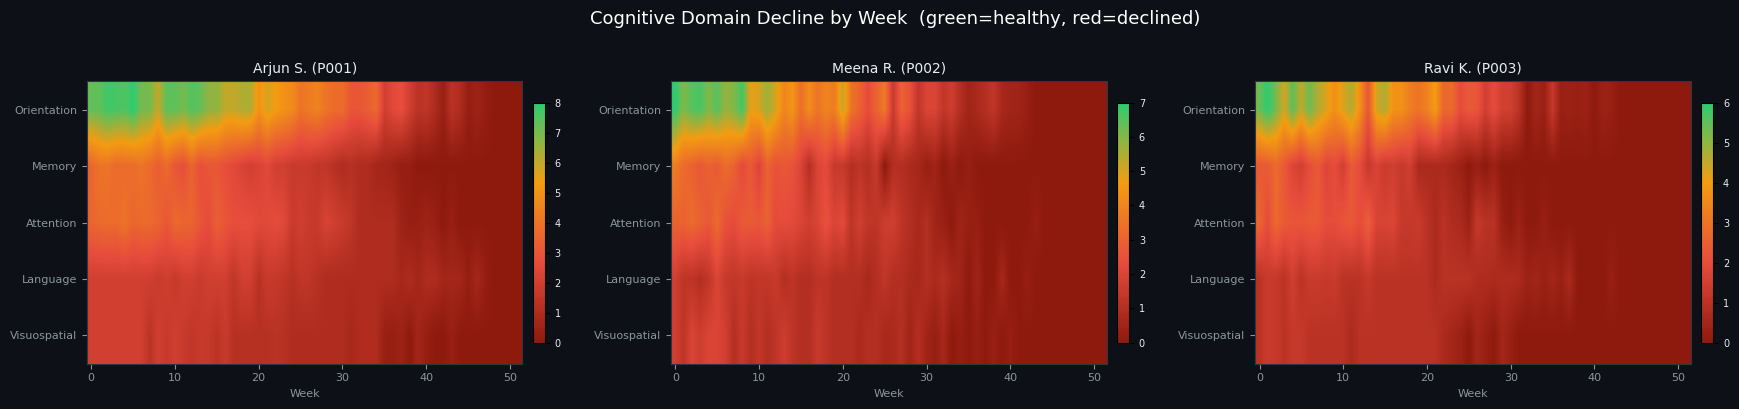

In [11]:
cmap_alz = LinearSegmentedColormap.from_list("alz", ["#8e1a0e","#e74c3c","#f39c12","#2ecc71"])
cat_cols  = ["score_orientation","score_memory","score_attention","score_language","score_visuospatial"]
cat_labels= ["Orientation","Memory","Attention","Language","Visuospatial"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor="#0d1117")
fig.suptitle("Cognitive Domain Decline by Week  (green=healthy, red=declined)",
             fontsize=13, color="white", y=1.01)

for ax, (pid, df) in zip(axes, patients.items()):
    ax.set_facecolor(BG)
    p = PATIENT_PROFILES[pid]
    weekly = df.groupby("week")[cat_cols].mean()
    im = ax.imshow(weekly.T, aspect="auto", cmap=cmap_alz, vmin=0, interpolation="bilinear")
    ax.set_yticks(range(len(cat_labels)))
    ax.set_yticklabels(cat_labels, fontsize=9, color=TEXT)
    ax.set_xlabel("Week", fontsize=8, color=MUTED)
    ax.set_title(f"{p['name']} ({pid})", fontsize=10, color=TEXT, pad=6)
    ax.tick_params(colors=MUTED, labelsize=8)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.ax.tick_params(labelcolor=TEXT, labelsize=7)

plt.tight_layout()
plt.show()


### 4.4 — Stage Distribution by Month

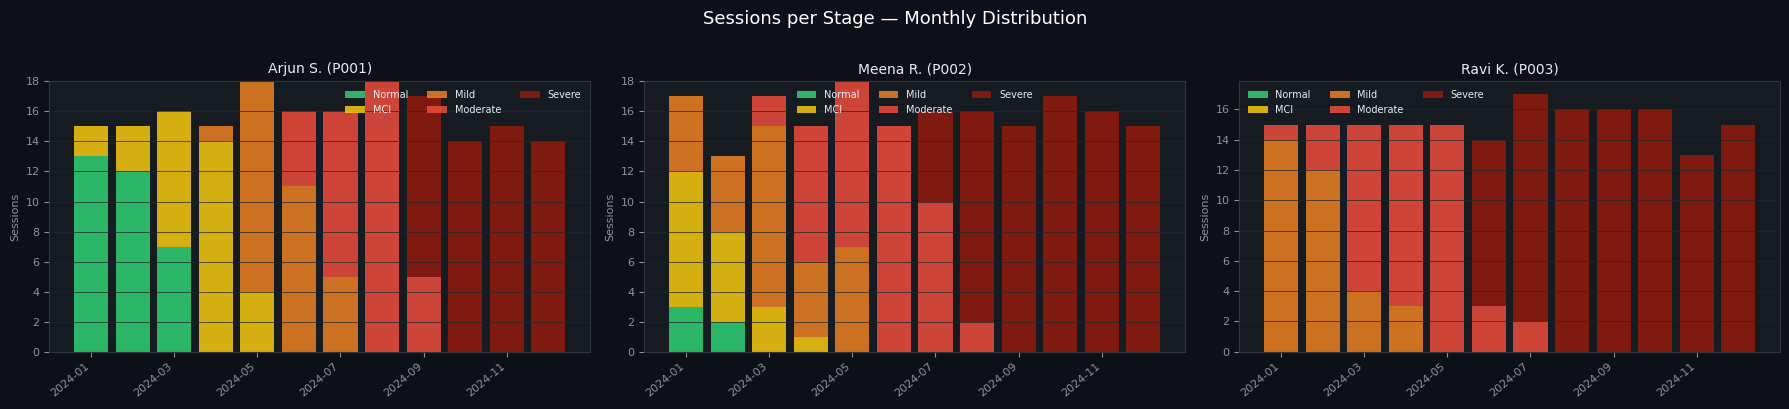

In [12]:
stage_order = ["Normal","MCI","Mild","Moderate","Severe"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor="#0d1117")
fig.suptitle("Sessions per Stage — Monthly Distribution",
             fontsize=13, color="white", y=1.01)

for ax, (pid, df) in zip(axes, patients.items()):
    ax.set_facecolor(BG)
    p = PATIENT_PROFILES[pid]
    df2 = df.copy()
    df2["month"] = pd.to_datetime(df2["date"]).dt.to_period("M")
    sc = df2.groupby(["month","stage"]).size().unstack(fill_value=0)
    sc = sc.reindex(columns=stage_order, fill_value=0)
    x = np.arange(len(sc)); bottoms = np.zeros(len(sc))
    months = [str(m) for m in sc.index]
    for sname in stage_order:
        if sname not in sc.columns: continue
        vals = sc[sname].values
        ax.bar(x, vals, bottom=bottoms, color=STAGE_COLORS[sname],
               width=0.82, alpha=0.88, label=sname)
        bottoms += vals
    ax.set_xticks(x[::2])
    ax.set_xticklabels(months[::2], rotation=40, ha="right", fontsize=7, color=MUTED)
    ax.set_ylabel("Sessions", fontsize=8, color=MUTED)
    ax.set_title(f"{p['name']} ({pid})", fontsize=10, color=TEXT, pad=6)
    ax.tick_params(colors=MUTED, labelsize=8)
    ax.grid(True, axis="y", color=GRID, linewidth=0.5)
    for sp in ax.spines.values(): sp.set_color(BORDER)
    ax.legend(fontsize=7, framealpha=0, labelcolor=TEXT, ncol=3)

plt.tight_layout()
plt.show()


## 5. Weekly Statistics Summary

In [13]:
# Weekly mean, min, max per patient
weekly_stats = (
    all_data
    .groupby(["patient_id","patient_name","week"])["total_score"]
    .agg(mean_score="mean", min_score="min", max_score="max", sessions="count")
    .reset_index()
)
weekly_stats["mean_score"] = weekly_stats["mean_score"].round(2)
weekly_stats["stage"] = weekly_stats["mean_score"].apply(lambda x: get_stage(int(round(x)))["name"])

# Show last 8 weeks per patient
pd.concat([
    weekly_stats[weekly_stats.patient_id == pid].tail(8)
    for pid in PATIENT_PROFILES
]).style.background_gradient(subset=["mean_score"], cmap="RdYlGn")


,patient_id,patient_name,week,mean_score,min_score,max_score,sessions,stage
44,P001,Arjun S.,45,1.670000,0,3,3,Severe
45,P001,Arjun S.,46,0.500000,0,1,4,Severe
46,P001,Arjun S.,47,1.250000,0,2,4,Severe
47,P001,Arjun S.,48,0.500000,0,2,4,Severe
48,P001,Arjun S.,49,0.000000,0,0,4,Severe
49,P001,Arjun S.,50,0.000000,0,0,3,Severe
50,P001,Arjun S.,51,0.000000,0,0,3,Severe
51,P001,Arjun S.,52,0.000000,0,0,3,Severe
96,P002,Meena R.,45,0.000000,0,0,4,Severe
97,P002,Meena R.,46,0.000000,0,0,4,Severe


## 6. How to Add a Real Patient

Replace the simulated data with actual quiz results. Just build a DataFrame with the same columns:

```python
import pandas as pd

real_patient = pd.DataFrame([
    # Add one row per quiz session
    {
        "patient_id": "P004", "patient_name": "New Patient",
        "session_num": 1, "date": "2024-01-02", "week": 1,
        "total_score": 17, "max_score": 20, "percentage": 85.0,
        "stage": "MCI",
        "score_orientation": 6, "score_memory": 4,
        "score_attention": 4, "score_language": 2, "score_visuospatial": 1,
    },
    # ... more sessions ...
])

# Then run prediction
res = predict_progression(real_patient, use_weeks=26)
print(res["current_stage"], res["predictions"])
```
